In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import glob
from PIL import Image

import numpy as np

from tqdm import tqdm
from torchvision.utils import save_image, make_grid
from torch.utils.data import Dataset
import torchvision.transforms as transforms

from tqdm import tqdm
from torch.optim import Adam

import math

In [2]:
# 0) download MNIST pretrained weights
!git clone https://gitlab.inria.fr/bchopin/tp-diffusion.git

Cloning into 'tp-diffusion'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 51.62 MiB | 10.96 MiB/s, done.


In [3]:
# 1) download dataset
!git clone https://gitlab.inria.fr/yaowang/gan_class_images.git

Cloning into 'gan_class_images'...
remote: Enumerating objects: 3, done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 3 (from 1)
Receiving objects: 100% (3/3), 111.92 MiB | 11.90 MiB/s, done.


In [4]:
!ls

gan_class_images  sample_data  tp-diffusion


In [5]:
!cd gan_class_images

In [6]:
# 2) cd images folder and unzip
!cd gan_class_images;unzip images.zip

Streaming output truncated to the last 5000 lines.
  inflating: images/32488.jpg        
  inflating: images/14625.jpg        
  inflating: images/6385.jpg         
  inflating: images/7921.jpg         
  inflating: images/18321.jpg        
  inflating: images/32888.jpg        
  inflating: images/1003.jpg         
  inflating: images/16799.jpg        
  inflating: images/8748.jpg         
  inflating: images/8425.jpg         
  inflating: images/14554.jpg        
  inflating: images/14586.jpg        
  inflating: images/36729.jpg        
  inflating: images/35430.jpg        
  inflating: images/10188.jpg        
  inflating: images/1673.jpg         
  inflating: images/36356.jpg        
  inflating: images/27328.jpg        
  inflating: images/1712.jpg         
  inflating: images/440.jpg          
  inflating: images/30384.jpg        
  inflating: images/27859.jpg        
  inflating: images/28374.jpg        
  inflating: images/14321.jpg        
  inflating: images/12997.jpg        

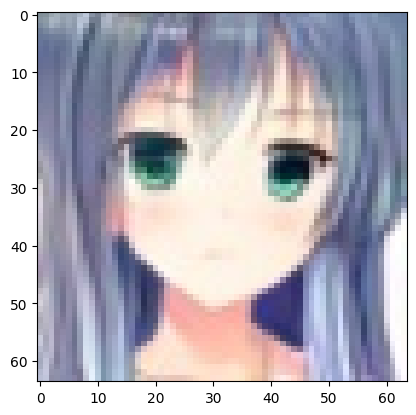

(64, 64, 3)


In [7]:
# 3) Display one image in the training set and the associated size

image1 = plt.imread("gan_class_images/images/822.jpg")
plt.imshow(image1)
plt.show()
print(image1.shape)


In [8]:
# 4) Prepare the MangaFace Dataset as training set with the help of *class*

class MangaFace(Dataset):
    def __init__(self, root, transform=None):
        """Initialize Pokemon."""
        self.transform = transform
        self.root = root
        self.imgs = glob.glob(self.root + '*')

    def __getitem__(self, idx):
        """Get item from Pokemon class.
        Args:
            index (int): Index
        Returns:
            img: PIL Image.
        """
        img = self.imgs[idx]
        img = Image.open(img).convert('RGB')

        if self.transform is not None:
            img = self.transform(img)

        return img

    def __len__(self):
        """Get length."""
        return len(self.imgs)

In [9]:

# MangaFace transform : normalize all image included on the loaded dataset :
train_transform = transforms.Compose([
                                      transforms.Resize((16,16)),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.ToTensor(),
                                      transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


In [10]:
# Model Hyperparameters

cuda = True
DEVICE = torch.device("cuda:0" if cuda else "cpu")


n_timesteps = 1000
beta_minmax=[1e-4, 2e-2]

train_batch_size = 64
inference_batch_size = 64
lr = 5e-5
epochs = 200

seed = 1234

torch.manual_seed(seed)
np.random.seed(seed)

In [14]:
from torchvision.datasets import MNIST, CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Transformation to be applied to MNIST data
transform = transforms.Compose([
        transforms.ToTensor(),
])

kwargs = {'num_workers': 1, 'pin_memory': True}

# Load MNIST dataset from torchvision.datasets
dataset_path = './datasets'
dataset = 'MNIST'
img_size =(28, 28, 1)
timestep_embedding_dim = 256
n_layers = 8
hidden_dim = 256

# S-TODO
train_dataset = MNIST(dataset_path, train=True, download=True, transform=transform)
test_dataset  = MNIST(dataset_path, train=False, download=True, transform=transform)
# E-TODO

# Load MangaFace dataset comment the MNIST load part and uncomment what comes below to switch to MangaFace dataset
#dataset = 'MFACE'
#img_size = (16, 16, 3)
#timestep_embedding_dim = 512
#n_layers = 16
#hidden_dim = 512
#train_dataset = MangaFace(root='./gan_class_images/images/', transform=train_transform)
#test_dataset = MangaFace(root='./gan_class_images/images/', transform=train_transform) # à changer

# Show the size :
hidden_dims = [hidden_dim for _ in range(n_layers)]
print("Size of the training set : ",len(train_dataset))

# S-TODO
train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True, **kwargs)
test_loader  = DataLoader(test_dataset, batch_size=inference_batch_size, shuffle=False, **kwargs)
# E-TODO

Size of the training set :  60000


In [15]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

In [16]:
class ConvBlock(nn.Conv2d):
    """
        Conv2D Block
            Args:
                x: (N, C_in, H, W)
            Returns:
                y: (N, C_out, H, W)
    """

    def __init__(self, in_channels, out_channels, kernel_size, activation_fn=None, drop_rate=0.,
                    stride=1, padding='same', dilation=1, groups=1, bias=True, gn=False, gn_groups=8):

        if padding == 'same':
            padding = kernel_size // 2 * dilation

        super(ConvBlock, self).__init__(in_channels, out_channels, kernel_size,
                                            stride=stride, padding=padding, dilation=dilation,
                                            groups=groups, bias=bias)

        self.activation_fn = nn.SiLU() if activation_fn else None
        self.group_norm = nn.GroupNorm(gn_groups, out_channels) if gn else None

    def forward(self, x, time_embedding=None, residual=False):

        if residual:
            # in the paper, diffusion timestep embedding was only applied to residual blocks of U-Net
            x = x + time_embedding
            y = x
            x = super(ConvBlock, self).forward(x)
            y = y + x
        else:
            y = super(ConvBlock, self).forward(x)
        y = self.group_norm(y) if self.group_norm is not None else y
        y = self.activation_fn(y) if self.activation_fn is not None else y

        return y

In [17]:
class Denoiser(nn.Module):

    def __init__(self, image_resolution, hidden_dims=[256, 256], diffusion_time_embedding_dim = 256, n_times=1000):
        super(Denoiser, self).__init__()

        _, _, img_C = image_resolution

        self.time_embedding = SinusoidalPosEmb(diffusion_time_embedding_dim)

        self.in_project = ConvBlock(img_C, hidden_dims[0], kernel_size=7)

        self.time_project = nn.Sequential(
                                 ConvBlock(diffusion_time_embedding_dim, hidden_dims[0], kernel_size=1, activation_fn=True),
                                 ConvBlock(hidden_dims[0], hidden_dims[0], kernel_size=1))

        self.convs = nn.ModuleList([ConvBlock(in_channels=hidden_dims[0], out_channels=hidden_dims[0], kernel_size=3)])

        for idx in range(1, len(hidden_dims)):
            self.convs.append(ConvBlock(hidden_dims[idx-1], hidden_dims[idx], kernel_size=3, dilation=3**((idx-1)//2),
                                                    activation_fn=True, gn=True, gn_groups=8))

        self.out_project = ConvBlock(hidden_dims[-1], out_channels=img_C, kernel_size=3)


    def forward(self, perturbed_x, diffusion_timestep):
        y = perturbed_x

        diffusion_embedding = self.time_embedding(diffusion_timestep)
        diffusion_embedding = self.time_project(diffusion_embedding.unsqueeze(-1).unsqueeze(-2))

        y = self.in_project(y)

        for i in range(len(self.convs)):
            y = self.convs[i](y, diffusion_embedding, residual = True)

        y = self.out_project(y)

        return y

model = Denoiser(image_resolution=img_size,
                 hidden_dims=hidden_dims,
                 diffusion_time_embedding_dim=timestep_embedding_dim,
                 n_times=n_timesteps).to(DEVICE)

# print tha model summary
print(model)

Denoiser(
  (time_embedding): SinusoidalPosEmb()
  (in_project): ConvBlock(1, 256, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
  (time_project): Sequential(
    (0): ConvBlock(
      256, 256, kernel_size=(1, 1), stride=(1, 1)
      (activation_fn): SiLU()
    )
    (1): ConvBlock(256, 256, kernel_size=(1, 1), stride=(1, 1))
  )
  (convs): ModuleList(
    (0): ConvBlock(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1-2): 2 x ConvBlock(
      256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)
      (activation_fn): SiLU()
      (group_norm): GroupNorm(8, 256, eps=1e-05, affine=True)
    )
    (3-4): 2 x ConvBlock(
      256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(3, 3), dilation=(3, 3)
      (activation_fn): SiLU()
      (group_norm): GroupNorm(8, 256, eps=1e-05, affine=True)
    )
    (5-6): 2 x ConvBlock(
      256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(9, 9), dilation=(9, 9)
      (activation_fn): SiLU()
      (group_norm): Gro

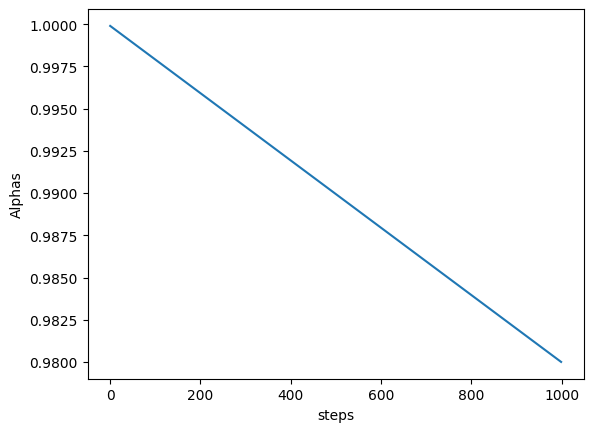

In [21]:
class Diffusion(nn.Module):
    def __init__(self, model, image_resolution=[32, 32, 3], n_times=1000, beta_minmax=[1e-4, 2e-2], device='cuda'):

        super(Diffusion, self).__init__()

        self.n_times = n_times
        self.img_H, self.img_W, self.img_C = image_resolution

        self.model = model

        # define linear variance schedule(betas)
        beta_1, beta_T = beta_minmax
        betas = torch.linspace(beta_1, beta_T, n_times).to(device)
        self.sqrt_betas = torch.sqrt(betas).to(device)

        # define alpha for forward diffusion kernel
        self.alphas = 1 - betas #TODO
        self.sqrt_alphas = torch.sqrt(self.alphas).to(device) #TODO
        alpha_bars = torch.cumprod(self.alphas, dim=0).to(device) #TODO
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1 - alpha_bars).to(device) #TODO
        self.sqrt_alpha_bars = torch.sqrt(alpha_bars).to(device) #TODO

        #plot alpha here
        import matplotlib.pyplot as plt
        plt.plot(self.alphas.cpu().detach().numpy())
        plt.ylabel('Alphas')
        plt.xlabel('steps')
        plt.show()

        self.device = device


    def extract(self, a, t, x_shape):
        b, *_ = t.shape
        out = a.gather(-1, t)
        return out.reshape(b, *((1,) * (len(x_shape) - 1)))


    def scale_to_minus_one_to_one(self, x):
        # according to the DDPMs paper, normalization seems to be crucial to train reverse process network
        # write a function that scales data to [-1, 1], given that the data is between 0 and 1
        return x * 2 - 1 #TODO

    def reverse_scale_to_zero_to_one(self, x):
        # write a function that re-scales data to [0, 1]
        return (x + 1) / 2 #TODO

# function that perturbs x_0 into x_t at a given timestep t (i.e., take x_0 samples into forward diffusion kernels)
    def make_noisy(self, x_zeros, t):
        epsilon = torch.randn_like(x_zeros).to(self.device) #TODO : finish with .to(self.device)
        sqrt_alpha_bar = self.extract(self.sqrt_alpha_bars, t, x_zeros.shape) #TODO
        sqrt_one_minus_alpha_bar = self.extract(self.sqrt_one_minus_alpha_bars, t, x_zeros.shape) #TODO
        noisy_sample = sqrt_alpha_bar * x_zeros + sqrt_one_minus_alpha_bar * epsilon #TODO
        return noisy_sample.detach(), epsilon


    def forward(self, x_zeros):
        # function that applies the forward diffusion process
        # scale input data to [-1, 1]
        x_zeros = self.scale_to_minus_one_to_one(x_zeros) #TODO
        B, _, _, _ = x_zeros.shape

        # (1) randomly choose diffusion time-step
        t= torch.randint(0, self.n_times, (B,), device=self.device).long()  #TODO

        # (2) forward diffusion process: perturb x_zeros with fixed variance schedule
        perturbed_images, epsilon = self.make_noisy(x_zeros, t) #TODO
        # (3) predict epsilon(noise) given perturbed data at diffusion-timestep t.
        pred_epsilon = self.model(perturbed_images, t) #TODO
        return perturbed_images, epsilon, pred_epsilon

    def forward_loop(self, x_zeros):
    #  function that returns the obtained images in all diffusion timesteps (will be used to create Gif file)
        # scale input data to [-1, 1]
        x_zeros = self.scale_to_minus_one_to_one(x_zeros) #TODO
        # list to save the output of each timetep
        x_T=[]
        B, _, _, _ = x_zeros.shape

        for t in range(self.n_times):
            timestep = torch.tensor([t]).repeat_interleave(B, dim=0).long().to(self.device)
           # (2) forward diffusion process: perturb x_zeros with fixed variance schedule
            perturbed_images, _ = self.make_noisy(x_zeros, timestep) #TODO
            x_T.append(self.reverse_scale_to_zero_to_one(perturbed_images)) #TODO
        return x_T


    def denoise_at_t(self, x_t, timestep, t):
    # Function that denoises x_t to x_t_minus_1 at a given timestep
        B, _, _, _ = x_t.shape

        if t > 1:
            z = torch.randn_like(x_t).to(self.device)
        else:
            z = torch.zeros_like(x_t).to(self.device)

        # at inference, we use predicted noise(epsilon) to restore perturbed data sample.
        epsilon_pred = self.model(x_t, timestep) #TODO

        alpha = self.extract(self.alphas, timestep, x_t.shape) #TODO
        sqrt_alpha = self.extract(self.sqrt_alphas, timestep, x_t.shape) #TODO
        sqrt_one_minus_alpha_bar =self.extract(self.sqrt_one_minus_alpha_bars, timestep, x_t.shape) #TODO
        sqrt_beta = self.extract(self.sqrt_betas, timestep, x_t.shape) #TODO

        # denoise at time t, utilizing predicted noise(give the equation)
        x_t_minus_1 = (x_t - epsilon_pred * sqrt_one_minus_alpha_bar) / sqrt_alpha + sqrt_beta * z #

        # clamp x_t_minus_1 between [-1,1]
        return x_t_minus_1.clamp(-1., 1)

    def sample(self, N):
    # Function that generates a sample x_0 with a list of generated images at all timesteps
        X=[]
        # start from random noise vector, x_0 (for simplicity, x_T declared as x_t instead of x_T)
        x_t = torch.randn(N, self.img_C, self.img_H, self.img_W).to(self.device) #TODO .to(self.device)

        # autoregressively denoise from x_T to x_0
        #     i.e., generate image from noise, x_0, while creating a list X with the obtained image at each timestep
        for t in range(self.n_times-1, -1, -1):
            timestep = torch.tensor([t]).repeat_interleave(N, dim=0).long().to(self.device)
            #Denoise
            x_t = self.denoise_at_t(x_t, timestep, t) #TODO
            # scale from 0 to 1
            x_tt= self.reverse_scale_to_zero_to_one(x_t) #TODO
            X.append(x_tt)
        # denormalize x_0 into 0 ~ 1 ranged values.
        x_0 = self.reverse_scale_to_zero_to_one(x_t) #
        return x_0, X

# define the diffusion model here
diffusion = Diffusion(model, image_resolution=img_size, n_times=n_timesteps, beta_minmax=beta_minmax, device=DEVICE) #TODO .to(DEVICE)

optimizer = Adam(diffusion.parameters(), lr=lr)

#Define loss function
denoising_loss = nn.MSELoss() #TODO

In [24]:
def count_parameters(model):
  #Count the number of trainable parameters
    return sum(p.numel() for p in model.parameters() if p.requires_grad) #TODO

print("Number of model parameters: ", count_parameters(diffusion))

Number of model parameters:  4870913


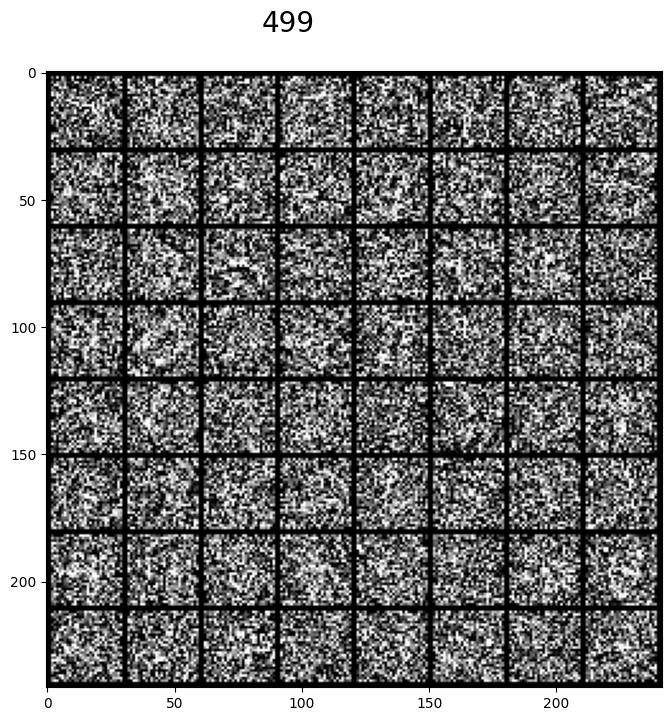

In [26]:
# 1) sample a batch of test images
model.eval()
if dataset=='MNIST':
    for batch_idx, (x,_) in enumerate(test_loader):
        x = x.to(DEVICE)
        #Perform forward process
        perturbed_images = diffusion.forward_loop(x) #TODO
        break
else:
    for batch_idx, x in enumerate(test_loader):
        x = x.to(DEVICE)
        #Perform forward process
        perturbed_images = diffusion.forward_loop(x) #TODO
        break

 #  Generate a Gif file to show the image evolution trought timesteps
import matplotlib.animation as animation
fig = plt.figure(figsize=(8,8))
ims = []
for i in range(500): #len(generated_inter_images)):
      title= plt.annotate(i,(.35, 1.1),horizontalalignment='left', verticalalignment='top', xycoords='axes fraction', fontsize=20)
      im = plt.imshow(np.transpose(make_grid(perturbed_images[i].detach().cpu()), (1, 2, 0)))
      ims.append([im,title])

animate = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)
animate.save('diffusion.gif')
plt.show()

Start training DDPMs...


100%|██████████| 938/938 [05:43<00:00,  2.73it/s]

	Epoch 1 complete! 	Denoising Loss:  0.06791339922207333



100%|██████████| 938/938 [05:41<00:00,  2.75it/s]

	Epoch 2 complete! 	Denoising Loss:  0.03538551284527066



100%|██████████| 938/938 [05:41<00:00,  2.75it/s]


	Epoch 3 complete! 	Denoising Loss:  0.0322590003300979
Finish!!


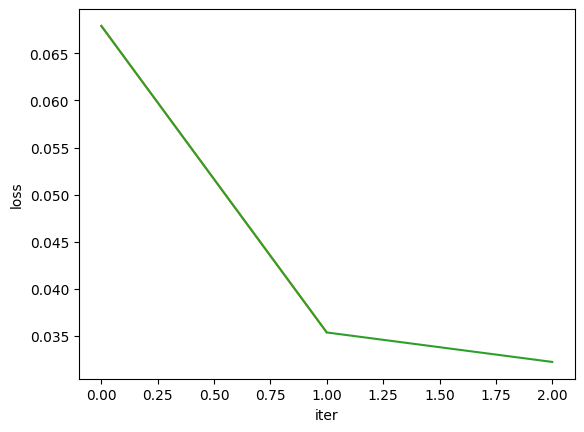

In [27]:
print("Start training DDPMs...")

model.train()
loss_evolution=[]
epochs=3 #1
for epoch in range(epochs):
    noise_prediction_loss = 0
    if dataset=='MNIST':
        for batch_idx, (x,_) in tqdm(enumerate(train_loader), total=len(train_loader)):
            #zero grad
            optimizer.zero_grad()
            x = x.to(DEVICE)
            #perform diffusion
            noisy_input, epsilon, pred_epsilon = diffusion(x)
            #Compute losss
            loss = denoising_loss(pred_epsilon, epsilon)
            noise_prediction_loss += loss.item()
            #backward propagation and optimization
            loss.backward()
            optimizer.step()

    else:
        for batch_idx, x in tqdm(enumerate(train_loader), total=len(train_loader)):
            #zero grad
            optimizer.zero_grad()
            x = x.to(DEVICE)
            #perform diffusion
            noisy_input, epsilon, pred_epsilon = diffusion(x)
            #Compute losss
            loss = denoising_loss(pred_epsilon, epsilon)
            noise_prediction_loss += loss.item()
            #backward propagation and optimization
            loss.backward()
            optimizer.step()
    print("\tEpoch", epoch + 1, "complete!", "\tDenoising Loss: ", noise_prediction_loss / batch_idx)
    loss_evolution.append(noise_prediction_loss / batch_idx)
    plt.plot(np.arange(len(loss_evolution)), loss_evolution)
    plt.xlabel("iter")
    plt.ylabel("loss")
    plt.savefig('result_loss_GPU.jpg')


#save model ('epoch', 'model_state_dict', 'optimizer_state_dict','loss','loss_evolution')
torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            'loss_evolution': loss_evolution
            }, "./model_GPU.pth")
print("Finish!!")

Start resuming DDPMs...


100%|██████████| 938/938 [05:41<00:00,  2.74it/s]


	Epoch 3 complete! 	Denoising Loss:  0.03052621616672808
Finish!!


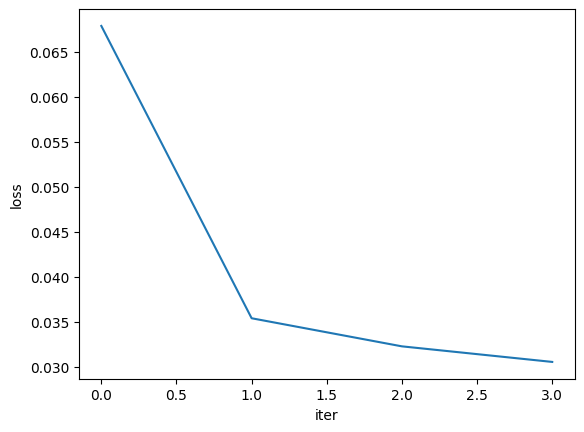

In [28]:
print("Start resuming DDPMs...")

#Restart training from pretrained weight
# Load model parameters:
checkpoint = torch.load("./model_GPU.pth")
#Load model param
model.load_state_dict(checkpoint['model_state_dict'])
#Load optimizer state
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
saved_epoch = checkpoint['epoch']
saved_loss = checkpoint['loss']
loss_evolution =checkpoint['loss_evolution']


model.train()
epochs=3 #MAX epoch to compute (saved_epoch + new_epochs)
for epoch in range(saved_epoch, epochs):
    noise_prediction_loss = 0
    if dataset=='MNIST':
        for batch_idx, (x,_) in tqdm(enumerate(train_loader), total=len(train_loader)):
            #zero grad
            optimizer.zero_grad()
            x = x.to(DEVICE)
            #perform diffusion
            noisy_input, epsilon, pred_epsilon = diffusion(x)
            #Compute losss
            loss = denoising_loss(pred_epsilon, epsilon)
            noise_prediction_loss += loss.item()
            #backward propagation and optimization
            loss.backward()
            optimizer.step()
    else:
        for batch_idx, x in tqdm(enumerate(train_loader), total=len(train_loader)):
            #zero grad
            optimizer.zero_grad()
            x = x.to(DEVICE)
            #perform diffusion
            noisy_input, epsilon, pred_epsilon = diffusion(x)
            #Compute losss
            loss = denoising_loss(pred_epsilon, epsilon)
            noise_prediction_loss += loss.item()
            #backward propagation and optimization
            loss.backward()
            optimizer.step()
    print("\tEpoch", epoch + 1, "complete!", "\tDenoising Loss: ", noise_prediction_loss / batch_idx)


# visualize the loss evolution
    loss_evolution.append(noise_prediction_loss / batch_idx)
    plt.plot(np.arange(len(loss_evolution)), loss_evolution)
    plt.xlabel("iter")
    plt.ylabel("loss")
    plt.savefig('result_loss_GPU.jpg')


# save the new model
#save model ('epoch', 'model_state_dict', 'optimizer_state_dict','loss','loss_evolution')
torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            'loss_evolution': loss_evolution
            }, "./model_GPU_MoreEpochs.pth")
print("Finish!!")

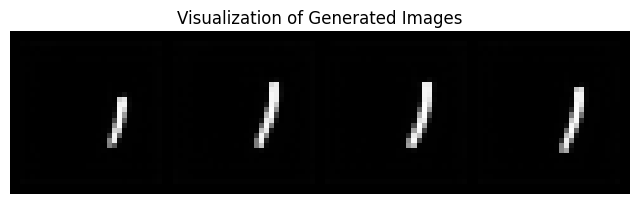

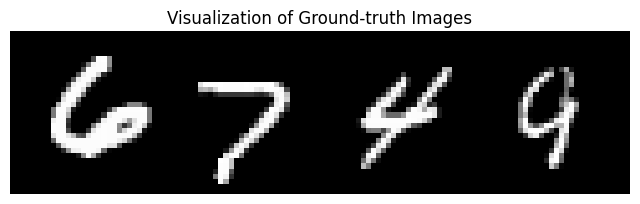

In [30]:
# Use the model to generate samples and visualize them
# Load model parameters that you just trained:


#TODO load checkpoint "./model_GPU_MoreEpochs.pth"
#TODO load model parameters
checkpoint = torch.load("./model_GPU_MoreEpochs.pth")
model.load_state_dict(checkpoint['model_state_dict'])

model.eval()
inference_batch_size=4
with torch.no_grad():
  #Generate samples
    generated_images, generated_inter_images = diffusion.sample(inference_batch_size) #TODO
# Visualize some Perturbed Images, Generated Images and Ground-truth Images  (I can remove this)
def draw_sample_image(x, postfix):
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title("Visualization of {}".format(postfix))
    plt.imshow(np.transpose(make_grid(x.detach().cpu(), padding=2, normalize=True), (1, 2, 0)))

# draw_sample_image(perturbed_images, "Perturbed Images")
draw_sample_image(generated_images, "Generated Images")
draw_sample_image(x[:inference_batch_size], "Ground-truth Images")

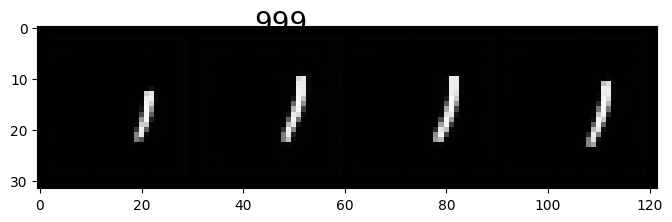

In [31]:
#  Generate a Gif file to visualize the image evolution trought the generation process (backward process)
import matplotlib.animation as animation

fig = plt.figure(figsize=(8,8))
ims = []
random_index = 1
for i in range(100, len(generated_inter_images)): #len(generated_inter_images)):
      title= plt.annotate(i,(.35, 1.1),horizontalalignment='left', verticalalignment='top', xycoords='axes fraction', fontsize=20)
      im = plt.imshow(np.transpose(make_grid(generated_inter_images[i].detach().cpu()), (1, 2, 0)))
      ims.append([im,title])

animate = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)
animate.save('diffusion_reverse.gif')
plt.show()

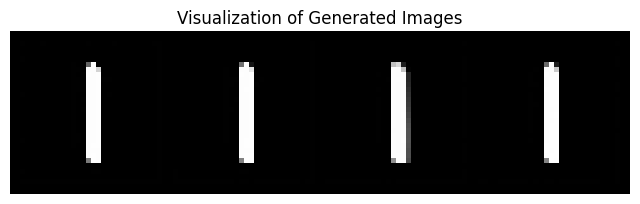

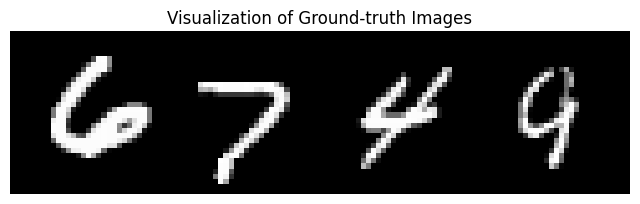

In [33]:
# Use the model to generate samples and visualize them
# Load model parameters that from the pretrained model of 210 epochs

#TODO load checkpoint "./tp-diffusion/model_MNIST_210.pth"
#TODO load model parameters
checkpoint = torch.load("./tp-diffusion/model_MNIST_210.pth")
model.load_state_dict(checkpoint['model_state_dict'])

model.eval()
inference_batch_size=4
with torch.no_grad():
  #Generate samples
    generated_images, generated_inter_images = diffusion.sample(inference_batch_size) #TODO

# Visualize some Perturbed Images, Generated Images and Ground-truth Images  (I can remove this)
def draw_sample_image(x, postfix):
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title("Visualization of {}".format(postfix))
    plt.imshow(np.transpose(make_grid(x.detach().cpu(), padding=2, normalize=True), (1, 2, 0)))

# draw_sample_image(perturbed_images, "Perturbed Images")
draw_sample_image(generated_images, "Generated Images")
draw_sample_image(x[:inference_batch_size], "Ground-truth Images")